## **Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

 ## **Load Data**

In [55]:
data_path = "../data_set/social_media_productivity_6000.csv"
df = pd.read_csv(data_path)

print(df.shape)

(6000, 9)


## **Data Analysis**

In [56]:
# Display all columns and rows
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


#### Exploratory Data Analysis

In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5880 non-null   float64
 1   daily_screen_time      5880 non-null   float64
 2   social_media_hours     5880 non-null   float64
 3   study_hours            5880 non-null   float64
 4   sleep_hours            5880 non-null   float64
 5   notifications_per_day  5880 non-null   float64
 6   focus_score            5880 non-null   float64
 7   addiction_level        5880 non-null   str    
 8   productivity_score     5880 non-null   float64
dtypes: float64(8), str(1)
memory usage: 422.0 KB


In [58]:
df.describe()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,productivity_score
count,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000
mean,27.111395,6.923175,4.145915,4.069328,6.514270,159.781463,96.363531,37.614051
std,7.268430,2.859055,2.155496,2.309472,1.434351,81.044666,7.416839,27.603251
min,15.000000,2.000000,0.660000,0.000000,4.000000,20.000000,47.390000,0.000000
25%,21.000000,4.470000,2.400000,2.120000,5.270000,89.000000,96.360000,13.565000
50%,27.000000,6.860000,3.755000,4.115000,6.525000,160.000000,100.000000,36.200000
75%,33.000000,9.360000,5.540000,6.030000,7.730000,231.000000,100.000000,58.560000
max,39.000000,11.990000,10.660000,8.000000,9.000000,299.000000,100.000000,100.000000


In [59]:
int_features = df.select_dtypes(include=['int64']).columns #Find all integer features

In [60]:
float_features = df.select_dtypes(include=['float64']).columns #Find all float features

In [61]:
cat_features = df.select_dtypes(include=['object']).columns #Find all categorical features

C:\Users\Admin\AppData\Local\Temp\ipykernel_15480\3038699684.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = df.select_dtypes(include=['object']).columns #Find all categorical features


**Null Value Visualization**

<Axes: >

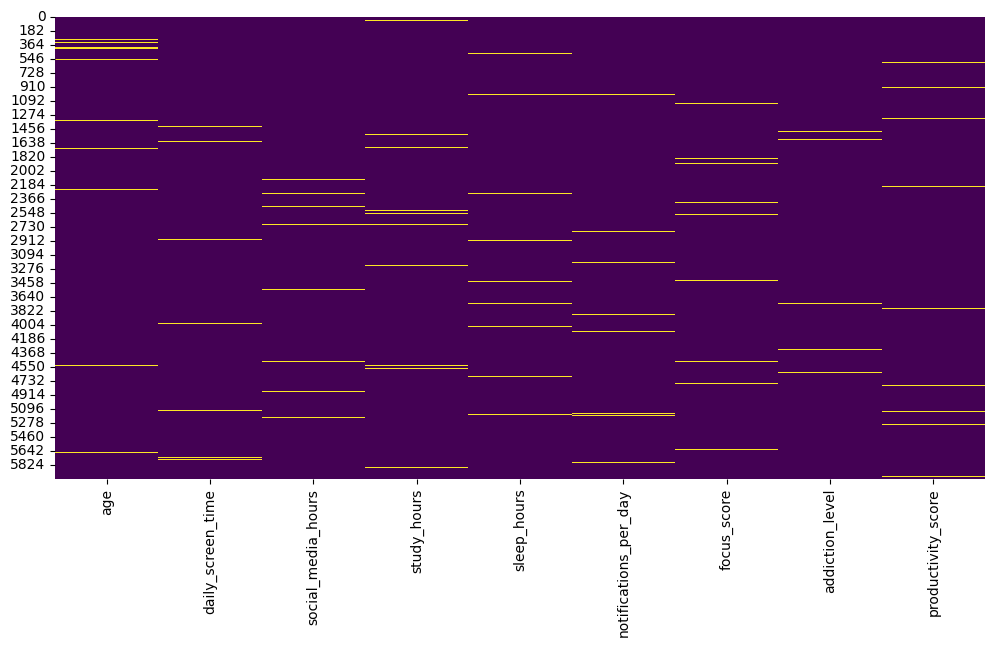

In [62]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

In [63]:
null_count = df.isnull().sum() # Calculate the number of null values in each column and store it in a variable called 'null_count'
null_percent = (null_count / len(df)) * 100 # Calculate the percentage of null values in each column and store it in a variable called 'null_percent'
# print(null_count)
print(null_percent)

age                      2.0
daily_screen_time        2.0
social_media_hours       2.0
study_hours              2.0
sleep_hours              2.0
notifications_per_day    2.0
focus_score              2.0
addiction_level          2.0
productivity_score       2.0
dtype: float64


#### Data Cleaning

In [64]:
df.dropna(inplace=True)
print(df.isnull().sum())

age                      0
daily_screen_time        0
social_media_hours       0
study_hours              0
sleep_hours              0
notifications_per_day    0
focus_score              0
addiction_level          0
productivity_score       0
dtype: int64


### Feature Transformation


Categorical to Numerical

In [65]:
df_encoded = df.copy() # Create a copy of the original DataFrame to work with encoding
addiction_level_mapping = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}
df_encoded['addiction_level'] = df_encoded['addiction_level'].map(addiction_level_mapping) # Map the 'Addiction_Level' column to numerical values using the defined mapping

Splitting Data

In [68]:
df_clean = df_encoded.sample(frac=1, random_state=42).reset_index(drop=True) # Randomly sample 80% of the data for training and reset the index
split_index = int(len(df_clean) * 0.8) # Calculate the index for an 80-20 split of the training data
df_train = df_clean[:split_index] # Create the training set using the first 80
df_test = df_clean[split_index:] # Create the testing set using the remaining 20%

X_train = df_clean.drop('productivity_score', axis=1) # Define the features for training by dropping the target variable
y_train = df_clean['productivity_score'] # Define the target variable for training

X_test = df_test.drop('productivity_score', axis=1) # Define the features for testing by dropping the target variable
y_test = df_test['productivity_score'] # Define the target variable for testing
